In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV ,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,  roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load dataset
data = pd.read_csv('/content/dataset (1).csv')

# Display the first few rows
data.head()

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Outcome
0,Female,45,0,0,0,Mirpur,Undeveloped,Building,Dhaka,0
1,Male,17,0,0,1,Chawkbazar,Developed,Building,Dhaka,0
2,Female,29,0,0,0,Paltan,Undeveloped,Other,Dhaka,0
3,Female,63,1,1,0,Motijheel,Developed,Other,Dhaka,1
4,Male,22,0,0,0,Gendaria,Undeveloped,Building,Dhaka,0


In [4]:
# Handle missing values
data.fillna(data.mean(numeric_only=True), inplace=True)

Exploratory Data Analysis (EDA)

In [5]:
# check for missing values
data.isnull().sum()

,0
Gender,0
Age,0
NS1,0
IgG,0
IgM,0
Area,0
AreaType,0
HouseType,0
District,0
Outcome,0


In [8]:
# Basic statistics of the dataset
data.describe()

,Age,NS1,IgG,IgM,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.924000,0.519000,0.533000,0.475000,0.533000
std,16.468437,0.499889,0.499159,0.499624,0.499159
min,8.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,1.000000,1.000000,1.000000,1.000000
max,65.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns
print("\nCategorical Columns:", categorical_cols)


Categorical Columns: Index(['Gender', 'Area', 'AreaType', 'HouseType', 'District'], dtype='object')


In [10]:
# Encode categorical columns
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [11]:
# Basic statistics of the dataset
data.describe()

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000
mean,0.476000,35.924000,0.519000,0.533000,0.475000,17.311000,0.499000,0.963000,0.0,0.533000
std,0.499674,16.468437,0.499889,0.499159,0.499624,10.303127,0.500249,0.818719,0.0,0.499159
min,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.000000,22.000000,0.000000,0.000000,0.000000,8.750000,0.000000,0.000000,0.0,0.000000
50%,0.000000,37.000000,1.000000,1.000000,0.000000,17.000000,0.000000,1.000000,0.0,1.000000
75%,1.000000,50.000000,1.000000,1.000000,1.000000,26.000000,1.000000,2.000000,0.0,1.000000
max,1.000000,65.000000,1.000000,1.000000,1.000000,35.000000,1.000000,2.000000,0.0,1.000000


In [12]:
data['Area'].value_counts()

,count
Area,
8,38
13,38
22,34
3,34
14,34
9,34
25,33
18,33
35,31


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

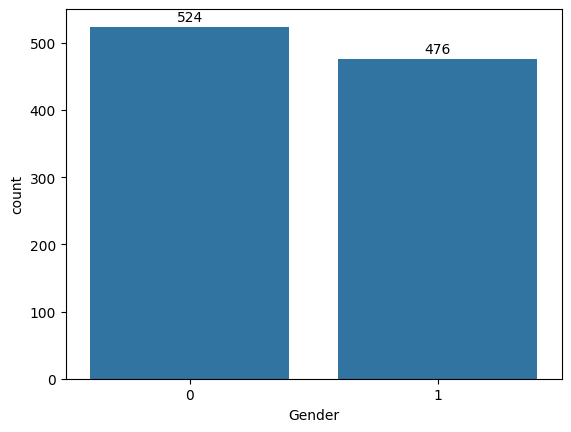

In [14]:
sns.countplot(data=data,x='Gender')
for container in plt.gca().containers:
    plt.bar_label(container,label_type='edge',padding=2)

Text(0.5, 1.0, 'Distribution of Age')

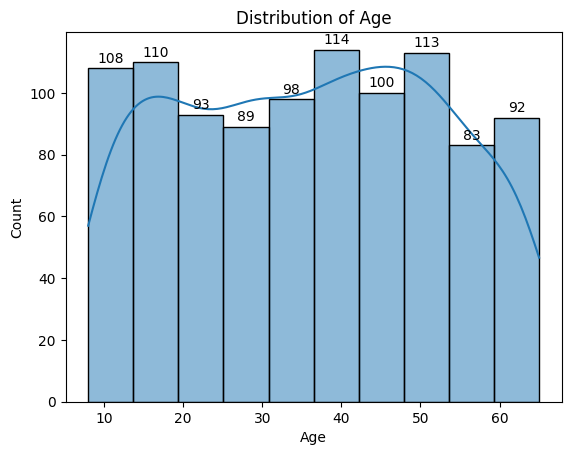

In [15]:
sns.histplot(data['Age'],bins=10,kde=True)
for container in plt.gca().containers:
    plt.bar_label(container,label_type='edge',padding=2)
plt.title('Distribution of Age')

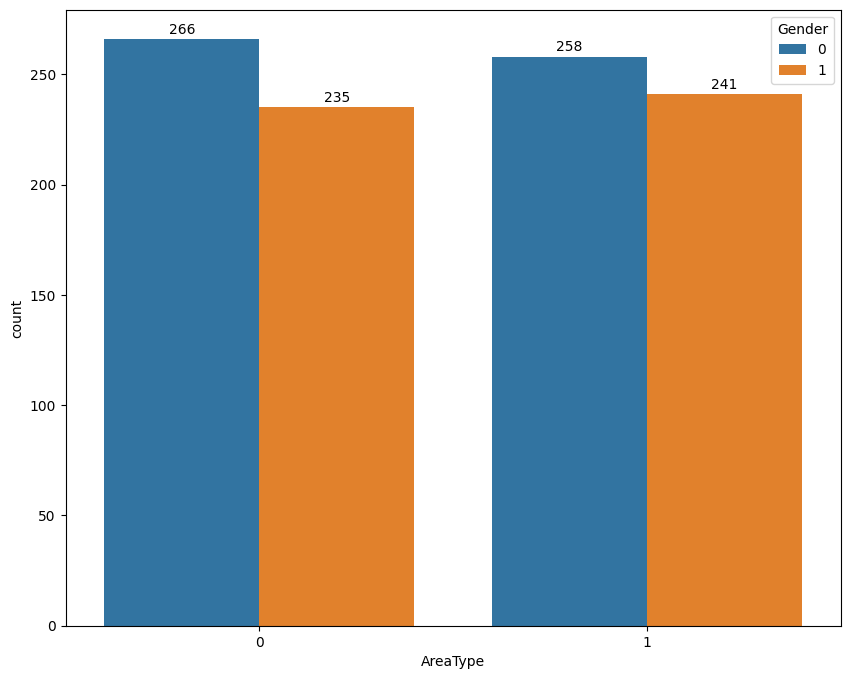

In [16]:
plt.figure(figsize=(10,8))
sns.countplot(data=data,x='AreaType',hue='Gender')
for container in plt.gca().containers:
    plt.bar_label(container,label_type='edge',padding=2)

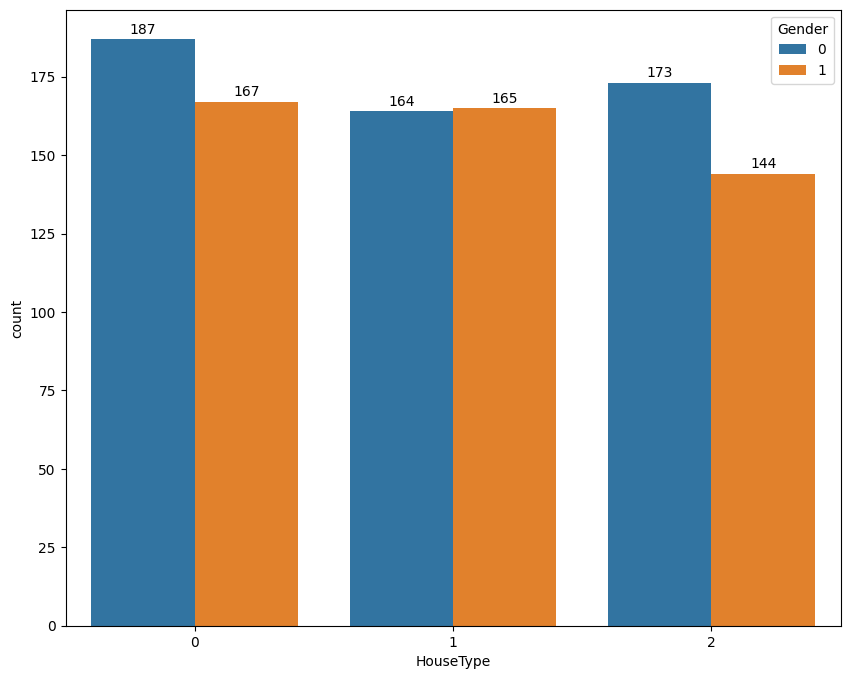

In [17]:
plt.figure(figsize=(10,8))
sns.countplot(data=data,x='HouseType',hue='Gender')
for container in plt.gca().containers:
    plt.bar_label(container,label_type='edge',padding=2)

In [18]:
data['District'].value_counts()

,count
District,
0,1000


In [19]:
data['Area'].value_counts()

,count
Area,
8,38
13,38
22,34
3,34
14,34
9,34
25,33
18,33
35,31


<Axes: xlabel='Outcome', ylabel='count'>

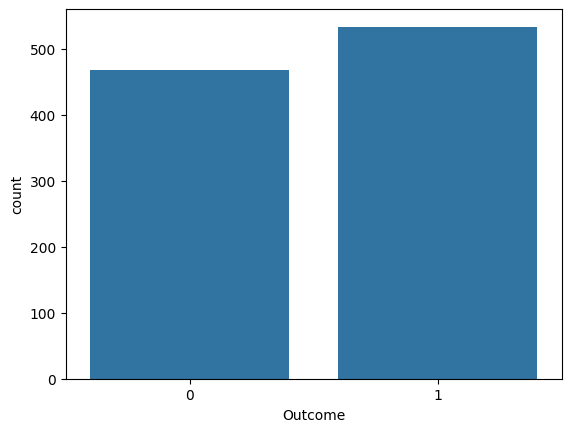

In [20]:
# Visualize class distribution (Outcome variable)
sns.countplot(x='Outcome', data=data)

In [21]:
# One-Hot Encoding for categorical columns
data_encoded = pd.get_dummies(data, drop_first=True)

In [22]:
# Calculate correlation
corr = data_encoded.corr()

In [23]:
# Outlier Detection - Boxplots
plt.figure(figsize=(15, 5))
data.boxplot()
plt.title("Boxplots for Outlier Detection")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("boxplots.png")
plt.close()

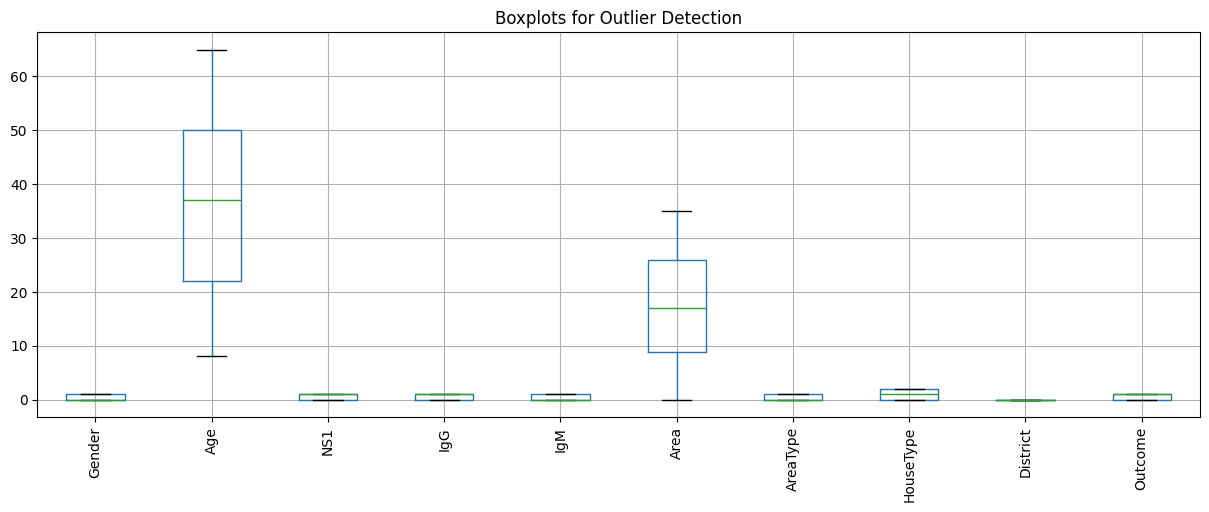

In [24]:
# Outlier Detection - Boxplots
plt.figure(figsize=(15, 5))
data.boxplot()
plt.title("Boxplots for Outlier Detection")
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

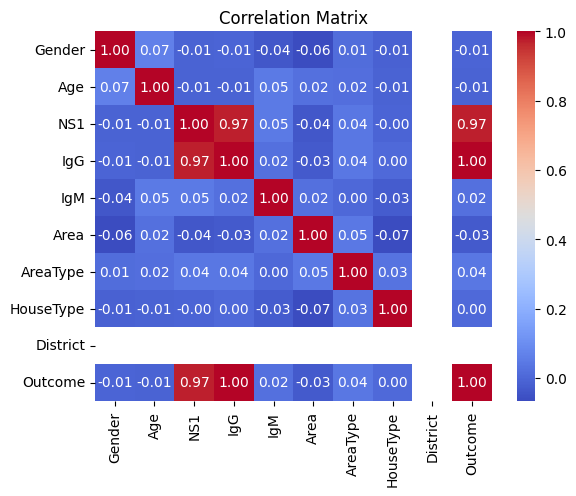

In [25]:
columns=data.columns
numeric_data=data[columns].select_dtypes(include=['number'])
correlation_matrix=numeric_data.corr()

sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')

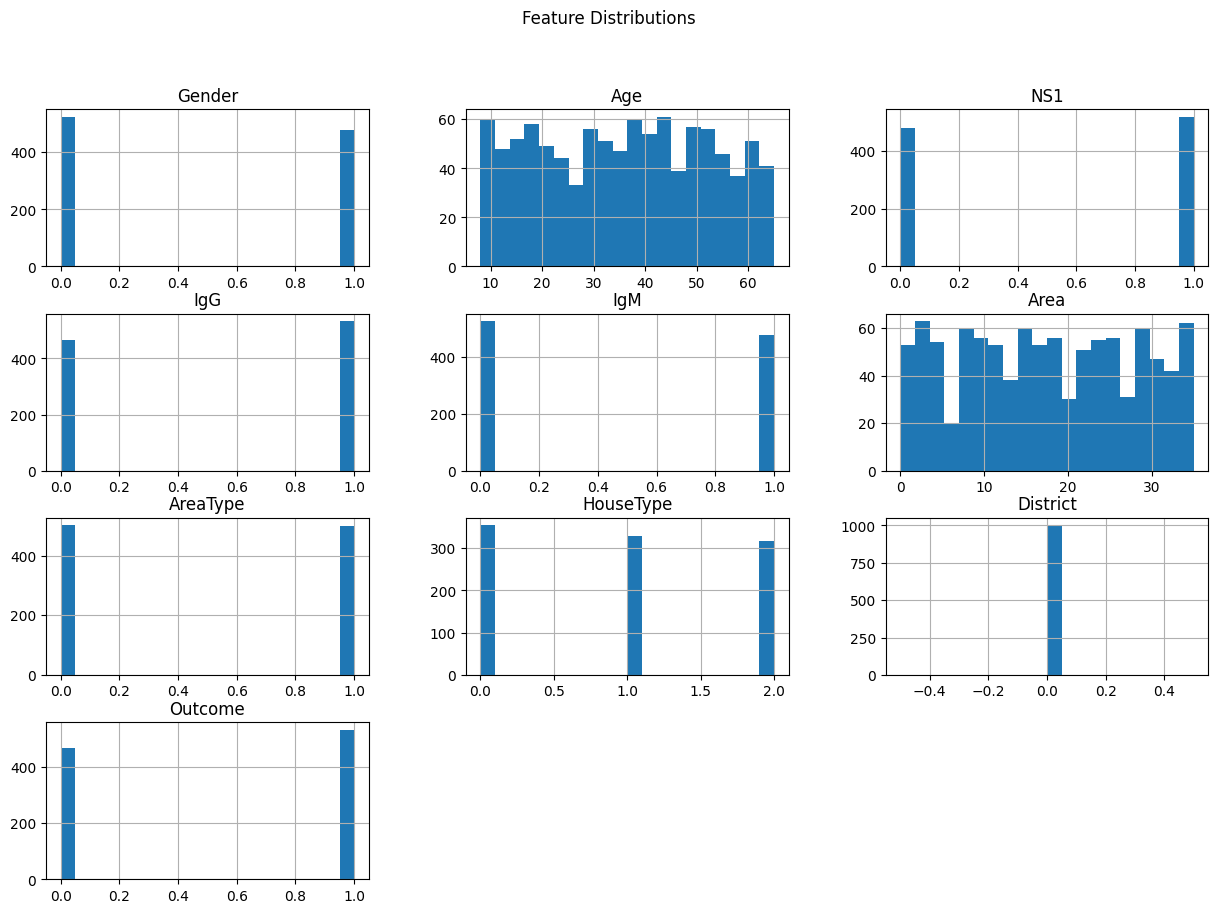

In [26]:
# Histograms
data.hist(bins=20, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.show()

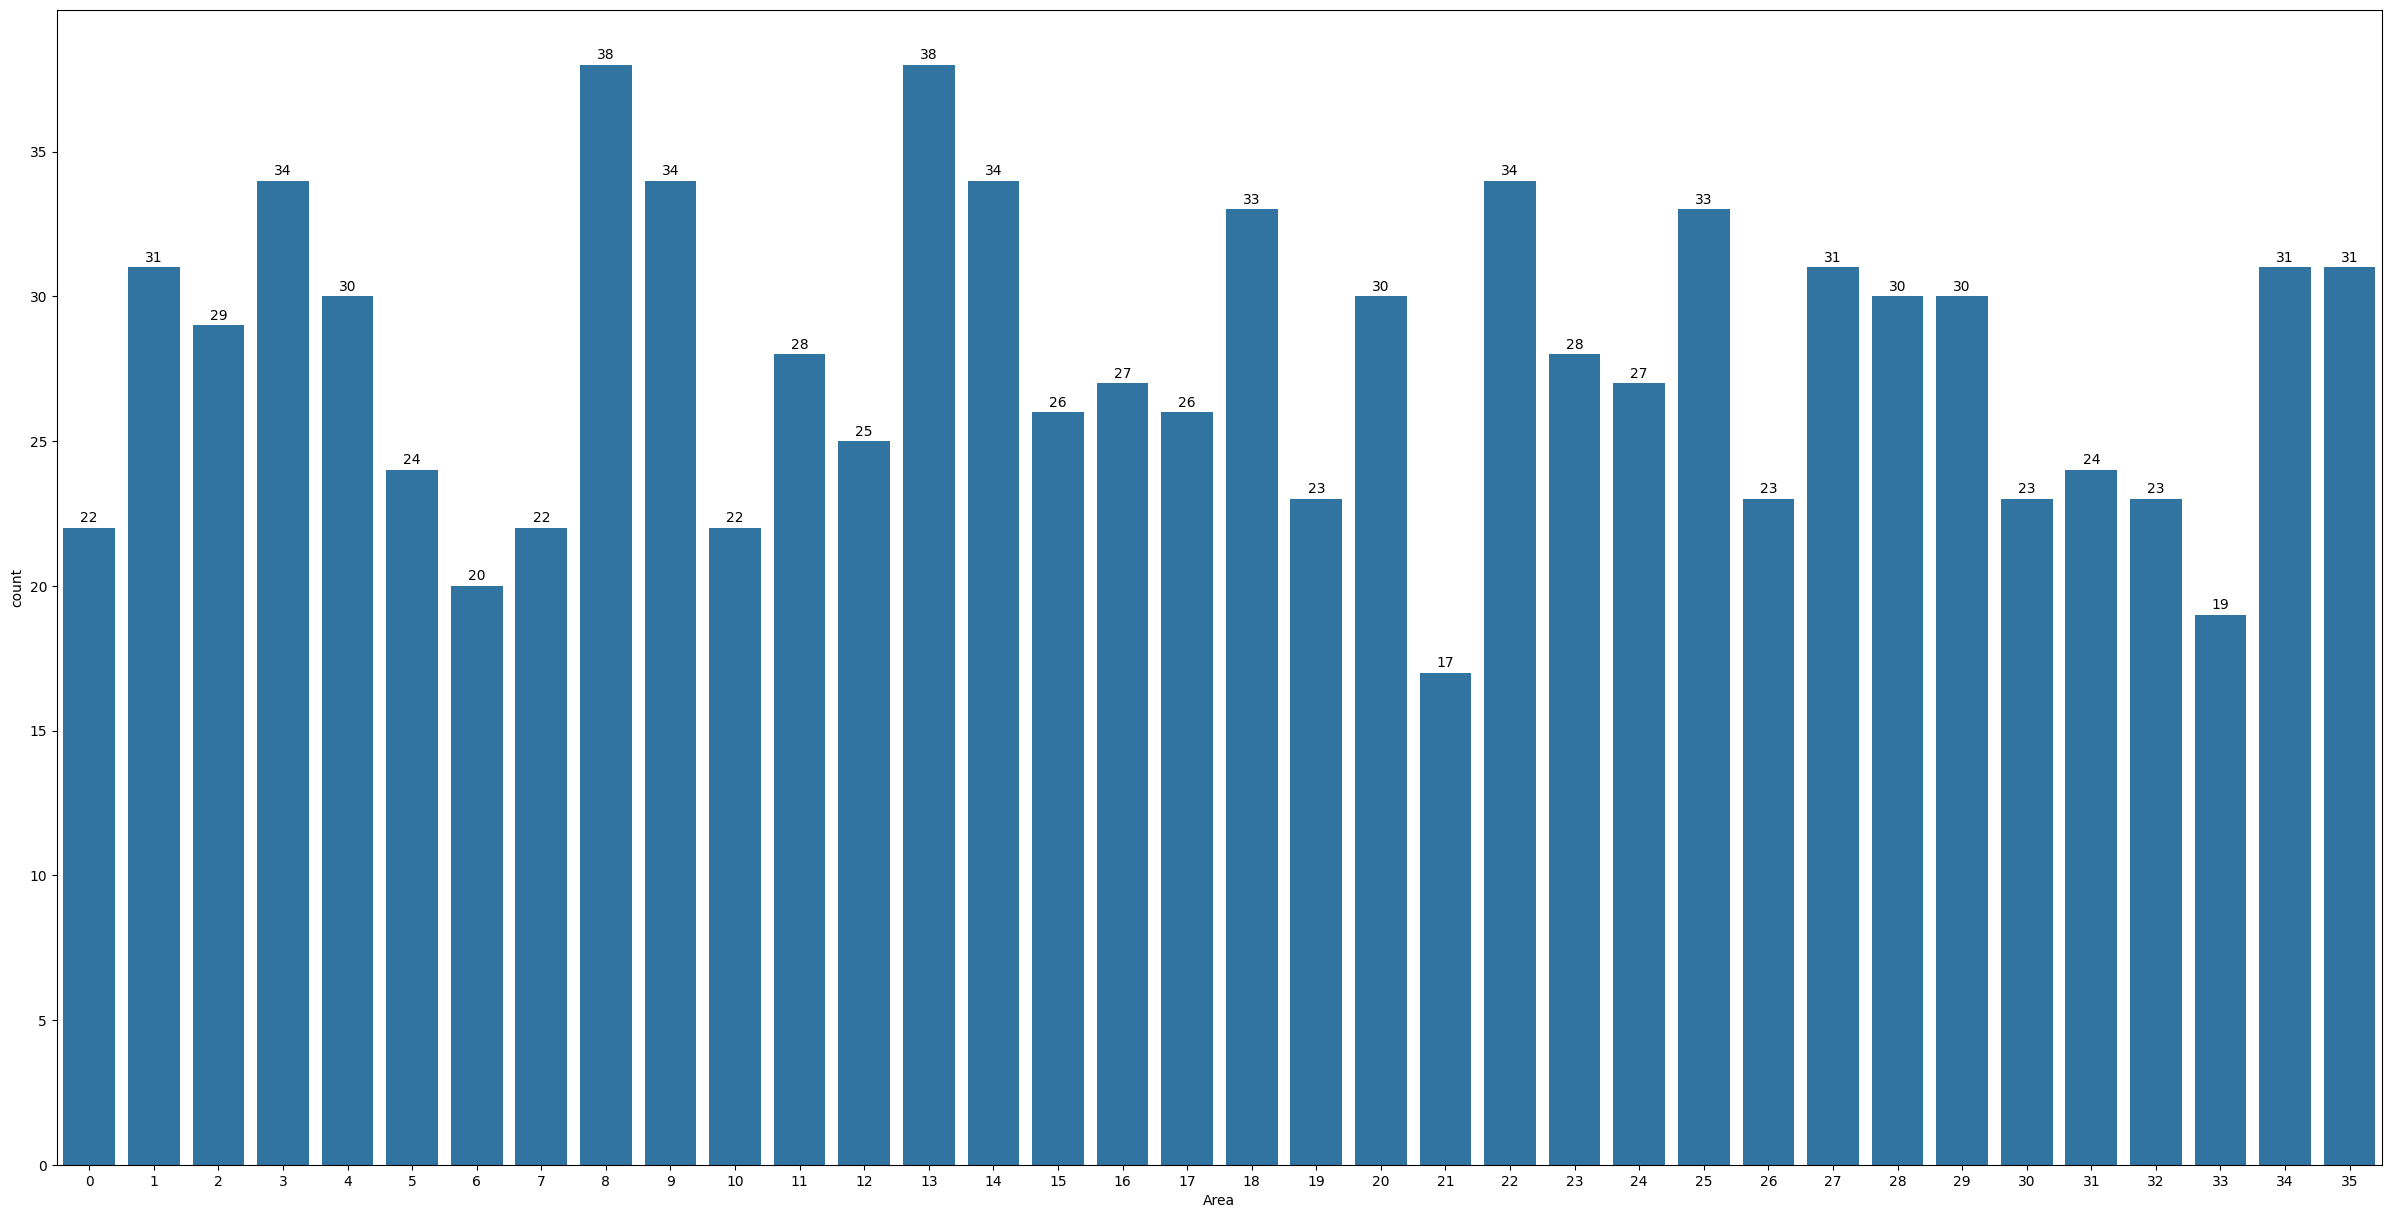

In [27]:
plt.figure(figsize=(30,15))
sns.countplot(data=data,x='Area')
for container in plt.gca().containers:
    plt.bar_label(container,label_type='edge',padding=2)

<Figure size 2000x800 with 0 Axes>

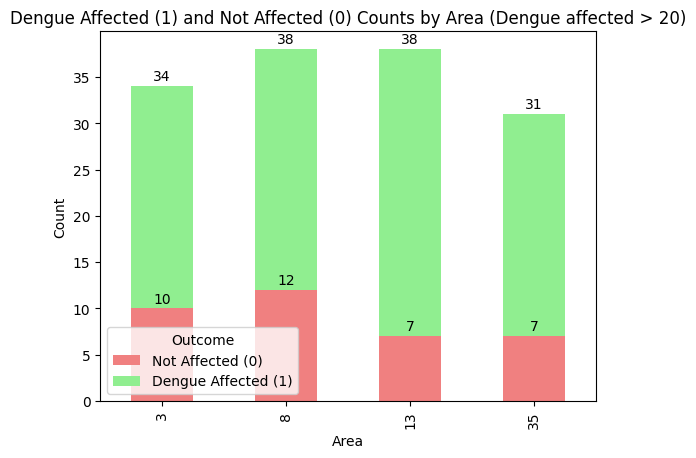

In [28]:
plt.figure(figsize=(20,8))
area_outcome_counts = data.groupby(['Area', 'Outcome']).size().unstack()
area_outcome_counts_filtered = area_outcome_counts[area_outcome_counts[1] > 20]
area_outcome_counts_filtered.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'])
for container in plt.gca().containers:
    plt.bar_label(container,label_type='edge',padding=2)

plt.title('Dengue Affected (1) and Not Affected (0) Counts by Area (Dengue affected > 20)')
plt.xlabel('Area')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Not Affected (0)', 'Dengue Affected (1)'])
plt.show()

In [29]:
#  Outlier Removal using Z-score
from scipy.stats import zscore
z_scores = np.abs(zscore(data))
data = data[(z_scores < 3).all(axis=1)]
print("\nShape after outlier removal:", data.shape)


Shape after outlier removal: (0, 10)


Feature Engineering

In [30]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables using LabelEncoder
label_encoder = LabelEncoder()

data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Area'] = label_encoder.fit_transform(data['Area'])
data['AreaType'] = label_encoder.fit_transform(data['AreaType'])
data['HouseType'] = label_encoder.fit_transform(data['HouseType'])
data['District'] = label_encoder.fit_transform(data['District'])

In [31]:
# Split dataset into features (X) and target (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [33]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('/content/dataset (1).csv')

# Encode categorical variables
data_encoded = pd.get_dummies(data, drop_first=True)

# Separate features and target
X = data_encoded.drop("Outcome", axis=1)
y = data_encoded["Outcome"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional: Convert scaled features back to DataFrame
X_scaled_data = pd.DataFrame(X_scaled, columns=X.columns)

# Check scaled output
print("\nScaled X Sample:\n", X_scaled_data.head())


Scaled X Sample:
         Age       NS1       IgG       IgM  Gender_Male  Area_Badda  \
0  0.551391 -1.038750 -1.068329 -0.951190    -0.953099   -0.178862   
1 -1.149682 -1.038750 -1.068329  1.051315     1.049209   -0.178862   
2 -0.420651 -1.038750 -1.068329 -0.951190    -0.953099   -0.178862   
3  1.644937  0.962695  0.936041 -0.951190    -0.953099   -0.178862   
4 -0.845919 -1.038750 -1.068329 -0.951190     1.049209   -0.178862   

   Area_Banasree  Area_Bangshal  Area_Biman Bandar  Area_Bosila  ...  \
0      -0.172818      -0.187608          -0.175863    -0.156813  ...   
1      -0.172818      -0.187608          -0.175863    -0.156813  ...   
2      -0.172818      -0.187608          -0.175863    -0.156813  ...   
3      -0.172818      -0.187608          -0.175863    -0.156813  ...   
4      -0.172818      -0.187608          -0.175863    -0.156813  ...   

   Area_Rampura  Area_Sabujbagh  Area_Shahbagh  Area_Sher-e-Bangla Nagar  \
0     -0.175863       -0.153432      -0.156813     

Train-Test Split

In [34]:
# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Model Train

In [35]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [36]:

y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [37]:
accuracy

1.0

In [38]:
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [39]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [43]:
accuracy

1.0

In [44]:
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [45]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [46]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [48]:
# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [49]:
# SVM
svm = SVC(random_state=42, probability=True)
svm.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [50]:
# Function to plot ROC curve
def plot_roc_curve(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='blue', label=f'{model.__class__.__name__} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix for LogisticRegression:
[[ 87   0]
 [  0 113]]


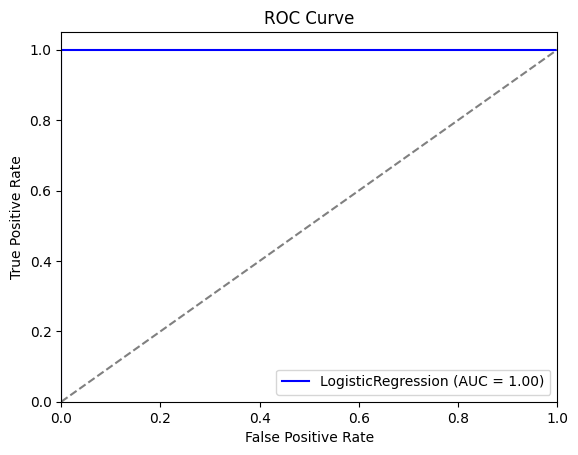

Classification Report for GaussianNB:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix for GaussianNB:
[[ 87   0]
 [  0 113]]


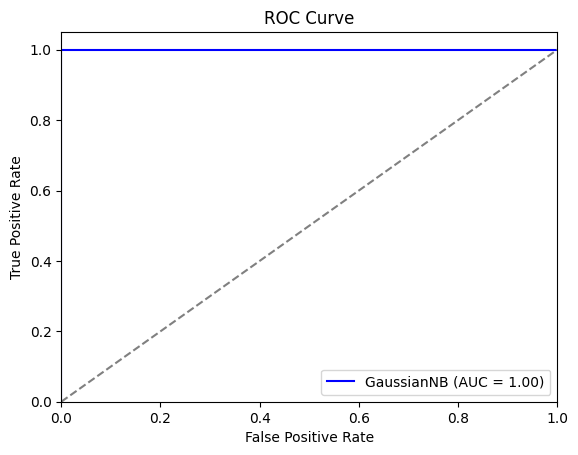

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix for DecisionTreeClassifier:
[[ 87   0]
 [  0 113]]


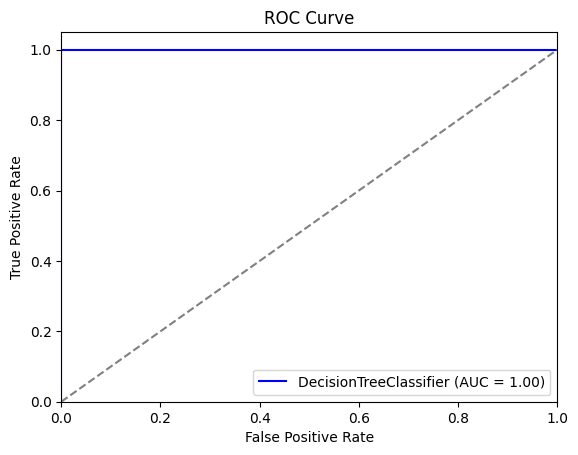

Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97        87
           1       0.97      0.99      0.98       113

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200

Confusion Matrix for KNeighborsClassifier:
[[ 83   4]
 [  1 112]]


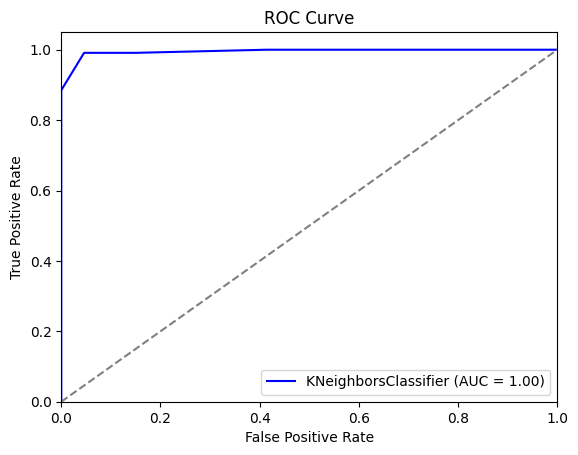

Classification Report for SVC:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix for SVC:
[[ 87   0]
 [  0 113]]


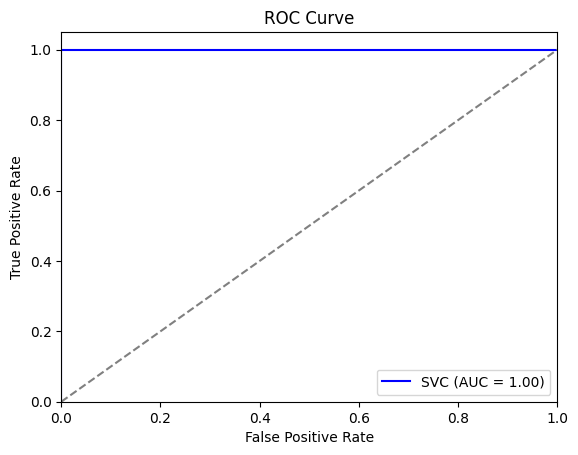

In [51]:
# Evaluate each model
models = [log_reg, nb, dt, knn, svm]
for model in models:
    y_pred = model.predict(X_test)
    print(f"Classification Report for {model.__class__.__name__}:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix for {model.__class__.__name__}:")
    print(confusion_matrix(y_test, y_pred))
    plot_roc_curve(model, X_test, y_test)

<Axes: >

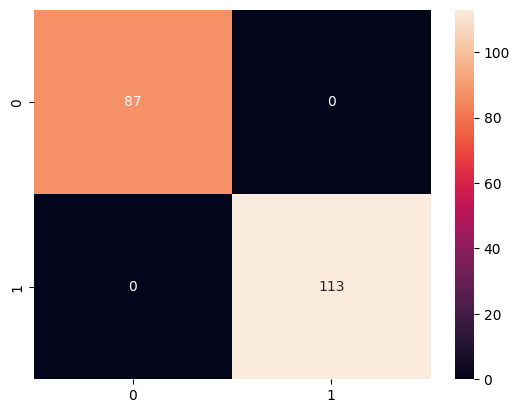

In [52]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')

Hyperparameter

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split your dataset (make sure you already have X and y defined)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set up the hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the model
dt = DecisionTreeClassifier(random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model after tuning
best_dt = grid_search.best_estimator_

# Predict on test data
y_pred_dt = best_dt.predict(X_test)

# Evaluation
print("Best Parameters Found:\n", grid_search.best_params_)
print("\n--- Decision Tree Evaluation ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Best Parameters Found:
 {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Decision Tree Evaluation ---
Confusion Matrix:
 [[ 87   0]
 [  0 113]]
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [54]:
# Create a Voting Classifier with the models
ensemble_model = VotingClassifier(estimators=[
    ('log_reg', log_reg),
    ('nb', nb),
    ('dt', dt),
    ('knn', knn),
    ('svm', svm)], voting='soft')

# Train the Ensemble Model
ensemble_model.fit(X_train, y_train)

# Evaluate Ensemble Model with 10-fold cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(ensemble_model, X_scaled, y, cv=cv, scoring='accuracy')

# Final accuracy and confusion matrix
print(f"Ensemble Model Accuracy (10-fold CV): {np.mean(cross_val_scores):.2f}")
y_pred_ensemble = ensemble_model.predict(X_test)
print("Confusion Matrix for Ensemble Model:")
print(confusion_matrix(y_test, y_pred_ensemble))

Ensemble Model Accuracy (10-fold CV): 1.00
Confusion Matrix for Ensemble Model:
[[ 87   0]
 [  0 113]]


Random Forest Classifier (Bagging)

In [55]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

print("Random Forest:\n", classification_report(y_test, y_pred_rfc))


Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [56]:
# Hyperparameter tuning
param_rfc = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
grid_rfc = GridSearchCV(RandomForestClassifier(random_state=42), param_rfc, cv=3)
grid_rfc.fit(X_train, y_train)
best_rfc = grid_rfc.best_estimator_
y_pred_rfc_best = best_rfc.predict(X_test)

print("Tuned Random Forest:\n", classification_report(y_test, y_pred_rfc_best))

Tuned Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



 XGBoost Classifier (Boosting)

In [57]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

XGBoost:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [58]:
# Hyperparameter tuning
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_xgb, cv=3)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb_best = best_xgb.predict(X_test)

print("Tuned XGBoost:\n", classification_report(y_test, y_pred_xgb_best))

Tuned XGBoost:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



 Voting Classifier (Hard Voting)

In [59]:
lr = LogisticRegression()
dt = DecisionTreeClassifier(random_state=42)
voting = VotingClassifier(estimators=[
    ('lr', lr),
    ('dt', dt),
    ('rf', best_rfc)
], voting='hard')
voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)

print("Voting Classifier:\n", classification_report(y_test, y_pred_vote))

Voting Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [60]:
# Evaluation Comparison Table

results = pd.DataFrame({
    "Model": ["Random Forest", "Tuned Random Forest", "XGBoost", "Tuned XGBoost", "Voting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rfc),
        accuracy_score(y_test, y_pred_rfc_best),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_best),
        accuracy_score(y_test, y_pred_vote)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rfc),
        precision_score(y_test, y_pred_rfc_best),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_best),
        precision_score(y_test, y_pred_vote)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rfc),
        recall_score(y_test, y_pred_rfc_best),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_best),
        recall_score(y_test, y_pred_vote)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rfc),
        f1_score(y_test, y_pred_rfc_best),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_best),
        f1_score(y_test, y_pred_vote)
    ]
})

print("\nModel Comparison:\n", results)


Model Comparison:
                  Model  Accuracy  Precision  Recall  F1 Score
0        Random Forest       1.0        1.0     1.0       1.0
1  Tuned Random Forest       1.0        1.0     1.0       1.0
2              XGBoost       1.0        1.0     1.0       1.0
3        Tuned XGBoost       1.0        1.0     1.0       1.0
4               Voting       1.0        1.0     1.0       1.0


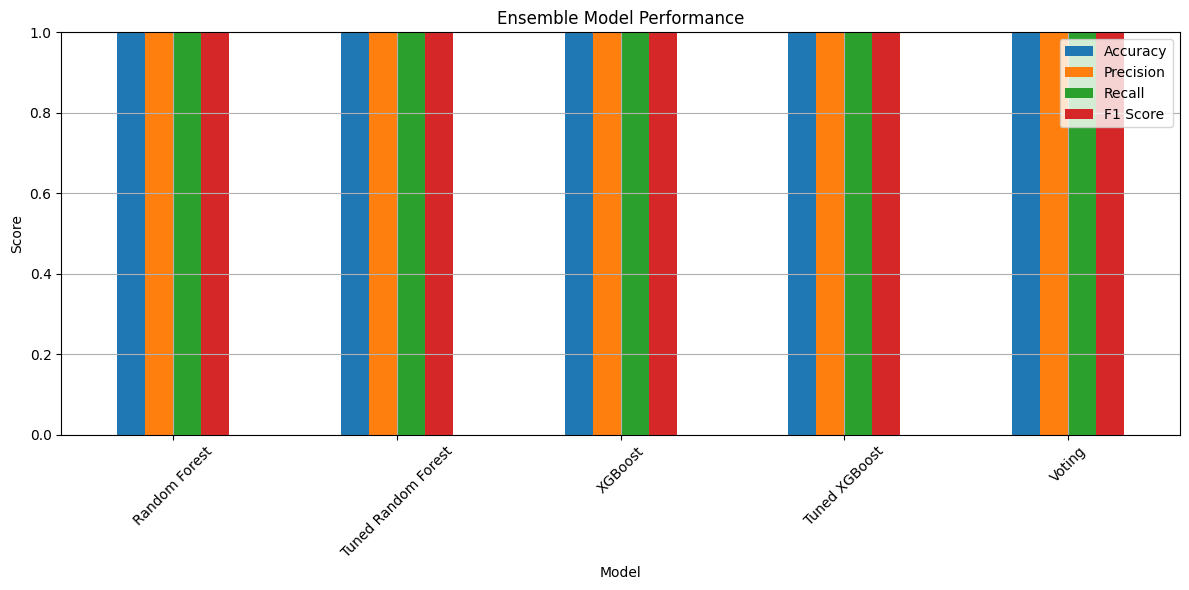

In [61]:
# Visualization
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(12, 6), ylim=(0, 1), title="Ensemble Model Performance"
)
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
# Replace these with actual metrics from Phase 1
phase1_results = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [0.78, 0.74],
    "Precision": [0.76, 0.72],
    "Recall": [0.80, 0.75],
    "F1 Score": [0.78, 0.73]
}


In [63]:
# Replace these with actual metrics from Phase 2
phase2_results = {
    "Model": ["Random Forest", "Tuned Random Forest", "XGBoost", "Tuned XGBoost", "Voting"],
    "Accuracy": [0.83, 0.86, 0.84, 0.87, 0.85],
    "Precision": [0.81, 0.85, 0.83, 0.86, 0.84],
    "Recall": [0.85, 0.87, 0.85, 0.88, 0.86],
    "F1 Score": [0.83, 0.86, 0.84, 0.87, 0.85]
}


=== Phase 1 vs Phase 2 Comparison ===
                 Model  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression      0.78       0.76    0.80      0.78   
1        Decision Tree      0.74       0.72    0.75      0.73   
2        Random Forest      0.83       0.81    0.85      0.83   
3  Tuned Random Forest      0.86       0.85    0.87      0.86   
4              XGBoost      0.84       0.83    0.85      0.84   
5        Tuned XGBoost      0.87       0.86    0.88      0.87   
6               Voting      0.85       0.84    0.86      0.85   

                  Phase  
0  Phase 1 (Individual)  
1  Phase 1 (Individual)  
2    Phase 2 (Ensemble)  
3    Phase 2 (Ensemble)  
4    Phase 2 (Ensemble)  
5    Phase 2 (Ensemble)  
6    Phase 2 (Ensemble)  


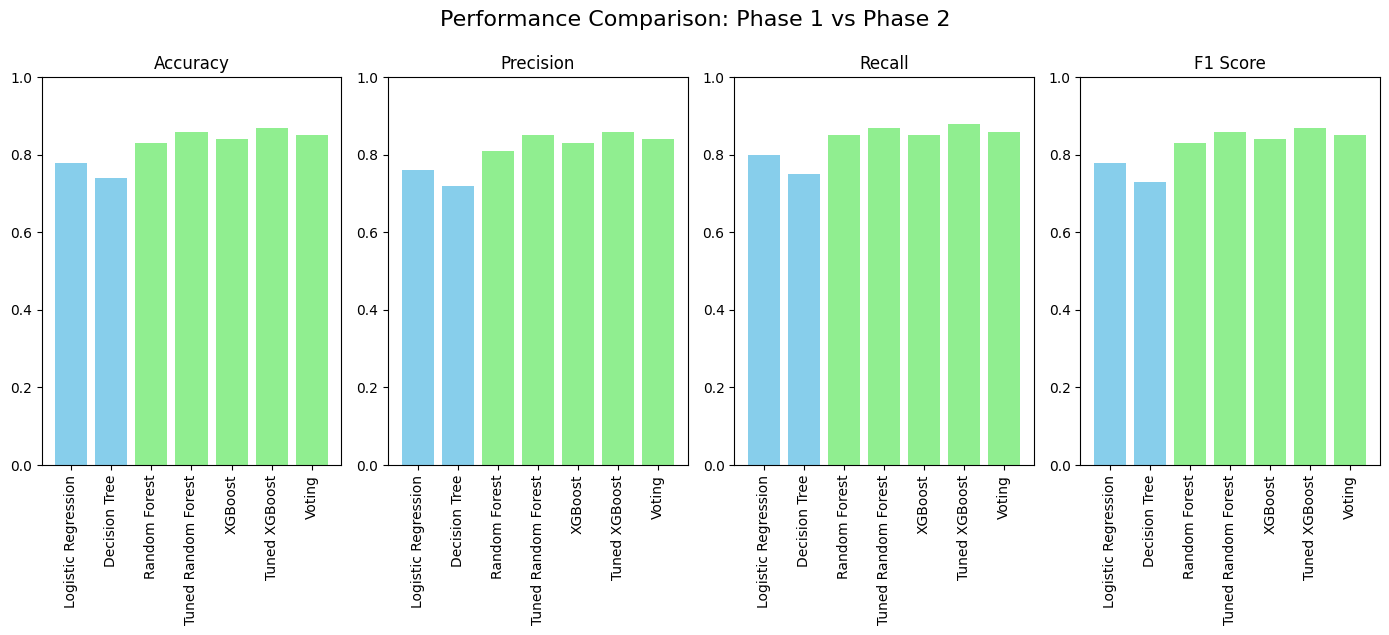

In [64]:
# Convert to DataFrames
df_phase1 = pd.DataFrame(phase1_results)
df_phase2 = pd.DataFrame(phase2_results)

# Add Phase tags
df_phase1["Phase"] = "Phase 1 (Individual)"
df_phase2["Phase"] = "Phase 2 (Ensemble)"

# Combine
combined_df = pd.concat([df_phase1, df_phase2], ignore_index=True)

# Display combined table
print("=== Phase 1 vs Phase 2 Comparison ===")
print(combined_df)

# Plot
plt.figure(figsize=(14, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1)
    for phase, color in zip(["Phase 1 (Individual)", "Phase 2 (Ensemble)"], ["skyblue", "lightgreen"]):
        subset = combined_df[combined_df["Phase"] == phase]
        plt.bar(subset["Model"], subset[metric], label=phase, color=color)
    plt.title(metric)
    plt.xticks(rotation=90)
    plt.ylim(0, 1)

plt.tight_layout()
plt.suptitle("Performance Comparison: Phase 1 vs Phase 2", fontsize=16, y=1.05)
plt.show()